<a href="https://colab.research.google.com/github/Mayar215999/data-science-project/blob/main/Artificial_Neural_Networks_deep_learning_m1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Artificial Neural Networks - Forward Propagation
Estimated time needed: 30 mins


Let's start by randomly initializing the weights and the biases in the network. We have 6 weights and 3 biases, one for each node in the hidden layer as well as for each node in the output layer.

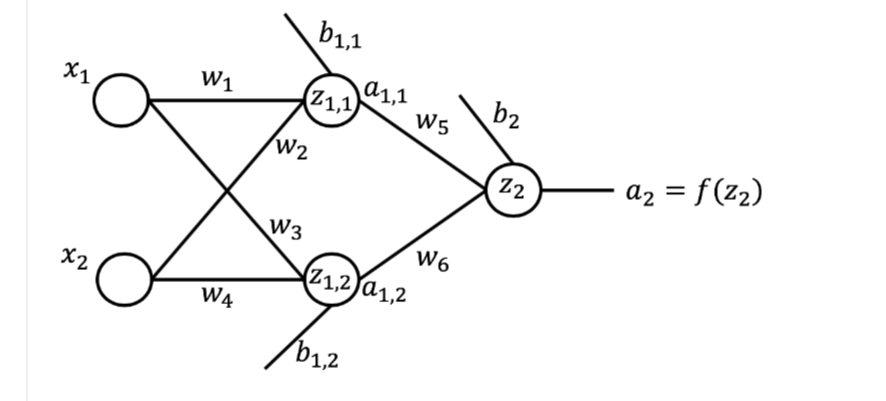

In [1]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# If you run this notebook on a different environment, e.g., your desktop, you may need to uncomment and install certain libraries.

#!pip install numpy==1.26.4

In [2]:
import numpy as np # import Numpy library to generate

weights = np.around(np.random.uniform(size=6), decimals=2) # initialize the weights
biases = np.around(np.random.uniform(size=3), decimals=2) # initialize the biases

In [3]:
print(weights)
print(biases)

[0.86 0.68 0.31 0.65 0.74 0.49]
[0.96 0.56 0.04]


In [4]:
x_1 = 0.5 # input 1
x_2 = 0.85 # input 2

print('x1 is {} and x2 is {}'.format(x_1, x_2))

x1 is 0.5 and x2 is 0.85


In [5]:
z_11 = x_1 * weights[0] + x_2 * weights[1] + biases[0]

print('The weighted sum of the inputs at the first node in the hidden layer is {}'.format(z_11))

The weighted sum of the inputs at the first node in the hidden layer is 1.968


In [8]:
z_12 = x_1 * weights[2] + x_2 * weights[3] + biases[1]
# --> is not valid Python syntax.  If you want a comment, use #

In [9]:
print('The weighted sum of the inputs at the second node in the hidden layer is {}'.format(np.around(z_12, decimals=4)))

The weighted sum of the inputs at the second node in the hidden layer is 1.2675


In [10]:
a_11 = 1.0 / (1.0 + np.exp(-z_11))

print('The activation of the first node in the hidden layer is {}'.format(np.around(a_11, decimals=4)))

The activation of the first node in the hidden layer is 0.8774


In [11]:
a_12 = 1.0 / (1.0 + np.exp(-z_12))


In [12]:
print('The activation of the second node in the hidden layer is {}'.format(np.around(a_12, decimals=4)))

The activation of the second node in the hidden layer is 0.7803


In [13]:
z_2 = a_11 * weights[4] + a_12 * weights[5] + biases[2]

In [14]:
print('The weighted sum of the inputs at the node in the output layer is {}'.format(np.around(z_2, decimals=4)))

The weighted sum of the inputs at the node in the output layer is 1.0716


In [15]:
a_2 = 1.0 / (1.0 + np.exp(-z_2))

In [16]:
print('The output of the network for x1 = 0.5 and x2 = 0.85 is {}'.format(np.around(a_2, decimals=4)))

The output of the network for x1 = 0.5 and x2 = 0.85 is 0.7449


Obviously, neural networks for real problems are composed of many hidden layers and many more nodes in each layer. So, we can't continue making predictions using this very inefficient approach of computing the weighted sum at each node and the activation of each node manually.

In order to code an automatic way of making predictions, let's generalize our network. A general network would take
𝑛
 inputs, would have many hidden layers, each hidden layer having
𝑚
 nodes, and would have an output layer. Although the network is showing one hidden layer, but we will code the network to have many hidden layers. Similarly, although the network shows an output layer with one node, we will code the network to have more than one node in the output layer.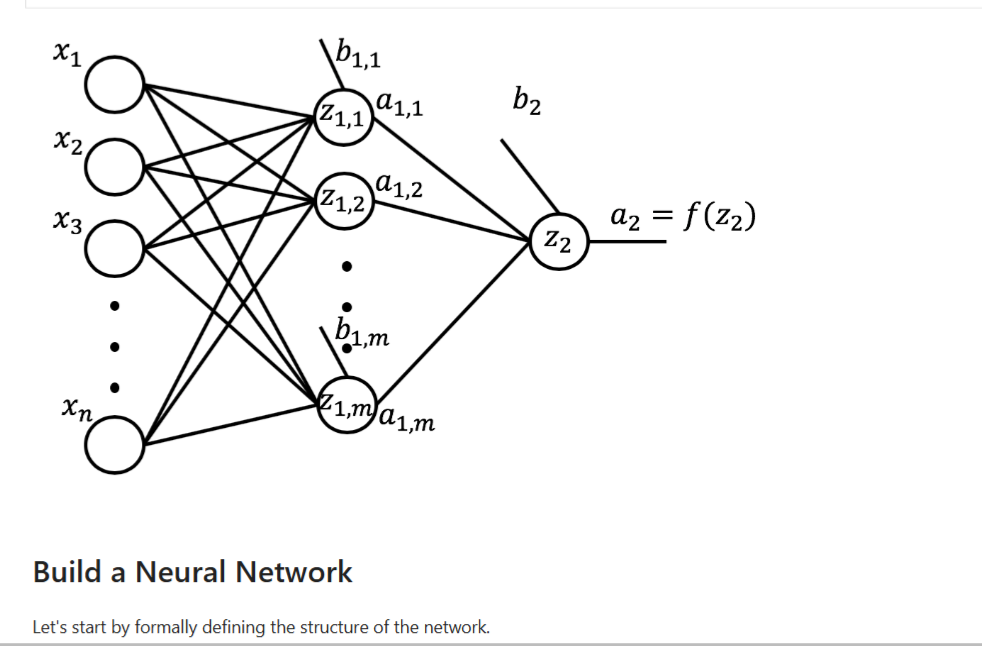

In [17]:
n = 2 # number of inputs
num_hidden_layers = 2 # number of hidden layers
m = [2, 2] # number of nodes in each hidden layer
num_nodes_output = 1 # number of nodes in the output layer

Now that we defined the structure of the network, let's go ahead and inititailize the weights and the biases in the network to random numbers. In order to be able to initialize the weights and the biases to random numbers, we will need to import the Numpy library.

In [18]:
import numpy as np # import the Numpy library

num_nodes_previous = n # number of nodes in the previous layer

network = {} # initialize network an an empty dictionary

# loop through each layer and randomly initialize the weights and biases associated with each node
# notice how we are adding 1 to the number of hidden layers in order to include the output layer
for layer in range(num_hidden_layers + 1):

    # determine name of layer
    if layer == num_hidden_layers:
        layer_name = 'output'
        num_nodes = num_nodes_output
    else:
        layer_name = 'layer_{}'.format(layer + 1)
        num_nodes = m[layer]

    # initialize weights and biases associated with each node in the current layer
    network[layer_name] = {}
    for node in range(num_nodes):
        node_name = 'node_{}'.format(node+1)
        network[layer_name][node_name] = {
            'weights': np.around(np.random.uniform(size=num_nodes_previous), decimals=2),
            'bias': np.around(np.random.uniform(size=1), decimals=2),
        }

    num_nodes_previous = num_nodes

print(network) # print network

{'layer_1': {'node_1': {'weights': array([0.76, 0.03]), 'bias': array([0.54])}, 'node_2': {'weights': array([0.71, 0.93]), 'bias': array([0.79])}}, 'layer_2': {'node_1': {'weights': array([0.11, 0.16]), 'bias': array([0.78])}, 'node_2': {'weights': array([0.94, 0.73]), 'bias': array([0.59])}}, 'output': {'node_1': {'weights': array([0.42, 0.37]), 'bias': array([0.72])}}}


Awesome! So now with the above code, we are able to initialize the weights and the biases pertaining to any network of any number of hidden layers and number of nodes in each layer. But let's put this code in a function so that we are able to repetitively execute all this code whenever we want to construct a neural network.

In [19]:
def initialize_network(num_inputs, num_hidden_layers, num_nodes_hidden, num_nodes_output):

    num_nodes_previous = num_inputs # number of nodes in the previous layer

    network = {}

    # loop through each layer and randomly initialize the weights and biases associated with each layer
    for layer in range(num_hidden_layers + 1):

        if layer == num_hidden_layers:
            layer_name = 'output' # name last layer in the network output
            num_nodes = num_nodes_output
        else:
            layer_name = 'layer_{}'.format(layer + 1) # otherwise give the layer a number
            num_nodes = num_nodes_hidden[layer]

        # initialize weights and bias for each node
        network[layer_name] = {}
        for node in range(num_nodes):
            node_name = 'node_{}'.format(node+1)
            network[layer_name][node_name] = {
                'weights': np.around(np.random.uniform(size=num_nodes_previous), decimals=2),
                'bias': np.around(np.random.uniform(size=1), decimals=2),
            }

        num_nodes_previous = num_nodes

    return network # return the network

Use the initialize_network function to create a network that:
takes 5 inputs
has three hidden layers
has 3 nodes in the first layer, 2 nodes in the second layer, and 3 nodes in the third layer
has 1 node in the output layer
Call the network small_network.

In [20]:
small_network = initialize_network(5, 3, [3, 2, 3], 1)

Compute Weighted Sum at Each Node
The weighted sum at each node is computed as the dot product of the inputs and the weights plus the bias. So let's create a function called compute_weighted_sum that does just that.

In [21]:
def compute_weighted_sum(inputs, weights, bias):
    return np.sum(inputs * weights) + bias

Let's generate 5 inputs that we can feed to small_network.

In [22]:
from random import seed
import numpy as np

np.random.seed(12)
inputs = np.around(np.random.uniform(size=5), decimals=2)

print('The inputs to the network are {}'.format(inputs))

The inputs to the network are [0.15 0.74 0.26 0.53 0.01]


Use the compute_weighted_sum function to compute the weighted sum at the first node in the first hidden layer.

In [23]:
node_weights = small_network['layer_1']['node_1']['weights']
node_bias = small_network['layer_1']['node_1']['bias']

weighted_sum = compute_weighted_sum(inputs, node_weights, node_bias)
print('The weighted sum at the first node in the hidden layer is {}'.format(np.around(weighted_sum[0], decimals=4)))

The weighted sum at the first node in the hidden layer is 1.4992


Compute Node Activation¶
Recall that the output of each node is simply a non-linear tranformation of the weighted sum. We use activation functions for this mapping. Let's use the sigmoid function as the activation function here. So let's define a function that takes a weighted sum as input and returns the non-linear transformation of the input using the sigmoid function.

In [24]:
def node_activation(weighted_sum):
    return 1.0 / (1.0 + np.exp(-1 * weighted_sum))

Use the node_activation function to compute the output of the first node in the first hidden layer.

In [25]:
node_output  = node_activation(compute_weighted_sum(inputs, node_weights, node_bias))
print('The output of the first node in the hidden layer is {}'.format(np.around(node_output[0], decimals=4)))

The output of the first node in the hidden layer is 0.8175


Forward Propagation
The final piece of building a neural network that can perform predictions is to put everything together. So let's create a function that applies the compute_weighted_sum and node_activation functions to each node in the network and propagates the data all the way to the output layer and outputs a prediction for each node in the output layer.

The way we are going to accomplish this is through the following procedure:

Start with the input layer as the input to the first hidden layer.
Compute the weighted sum at the nodes of the current layer.
Compute the output of the nodes of the current layer.
Set the output of the current layer to be the input to the next layer.
Move to the next layer in the network.
Repeat steps 2 - 4 until we compute the output of the output layer.

In [26]:
def forward_propagate(network, inputs):

    layer_inputs = list(inputs) # start with the input layer as the input to the first hidden layer

    for layer in network:

        layer_data = network[layer]

        layer_outputs = []
        for layer_node in layer_data:

            node_data = layer_data[layer_node]

            # compute the weighted sum and the output of each node at the same time
            node_output = node_activation(compute_weighted_sum(layer_inputs, node_data['weights'], node_data['bias']))
            layer_outputs.append(np.around(node_output[0], decimals=4))

        if layer != 'output':
            print('The outputs of the nodes in hidden layer number {} is {}'.format(layer.split('_')[1], layer_outputs))

        layer_inputs = layer_outputs # set the output of this layer to be the input to next layer

    network_predictions = layer_outputs
    return network_predictions

In [27]:
predictions = forward_propagate(small_network, inputs)
print('The predicted value by the network for the given input is {}'.format(np.around(predictions[0], decimals=4)))

The outputs of the nodes in hidden layer number 1 is [0.8175, 0.8463, 0.7149]
The outputs of the nodes in hidden layer number 2 is [0.8032, 0.8389]
The outputs of the nodes in hidden layer number 3 is [0.8755, 0.8252, 0.7476]
The predicted value by the network for the given input is 0.8377


So we built the code to define a neural network. We can specify the number of inputs that a neural network can take, the number of hidden layers as well as the number of nodes in each hidden layer, and the number of nodes in the output layer.

We first use the initialize_network to create our neural network and define its weights and biases.

In [28]:
my_network = initialize_network(5, 3, [2, 3, 2], 3)

In [29]:
inputs = np.around(np.random.uniform(size=5), decimals=2)

In [30]:
predictions = forward_propagate(my_network, inputs)
print('The predicted values by the network for the given input are {}'.format(predictions))

The outputs of the nodes in hidden layer number 1 is [0.8857, 0.8889]
The outputs of the nodes in hidden layer number 2 is [0.7822, 0.6965, 0.7411]
The outputs of the nodes in hidden layer number 3 is [0.868, 0.881]
The predicted values by the network for the given input are [0.8952, 0.8222, 0.8035]


In [31]:
network = {
    'n_inputs': 2,
    'n_hidden': 3,
    'n_outputs': 1
}

In [32]:
from IPython import get_ipython
from IPython.display import display
# %% [markdown]
# Artificial Neural Networks - Forward Propagation
# Estimated time needed: 30 mins
#
#
# Let's start by randomly initializing the weights and the biases in the network. We have 6 weights and 3 biases, one for each node in the hidden layer as well as for each node in the output layer.
#
# ![03.03.2025_00.23.05_REC.png](data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAA3YAAAGRCAYAAAApcyGeAAAACXBIWXMAAA7EAAAOxAGVKw4bAAAAFXRFWHRkZXZpY2VQaXhlbFJhdGlvADEuMjWOzsGWAAAgAElEQVR4nOzd+VNUd77/8efplWZtoGmaHQQFQTSIC2rcFTWaaNyS0SSTydTcOzN1594fbt2qqbq/5A+YunW3qZr5zkwy5kajRpO4xR0XXEBRwSD7vu/Q7NDL+f7gpW8cY6JGWfT9qKKycOjz6aabOq/z/nzeH0VVVZVx0NPTA4DZbB6P0wkhhBBCCCHES0Mz0QMQQgghhBBCCPHjSLATQgghhBBCiClOgp0QQgghhBBCTHES7IQQQgghhBBiipNgJ4QQQgghhBBTnAQ7IYQQQgghhJjiJNgJIYQQQgghxBQnwU4IIYQQQgghpjgJdkIIIYQQQggxxUmwE0IIIYQQQogpToKdEEIIIYQQQkxxuokegBDi5TEyMkJzczM6nQ6bzYZOJ3+ChBBCCCGeBbmqEkKMi5GREa5evcrevXuJiYnhZz/7GZGRkSiKMtFDE0IIIYSY8iTYCSGeu9HRUbKzs/n973/PhQsXiIyMxGazsXPnTsxm80QPTwghhBBiypM1dkKI506r1WIymRgZGaGvr4+Kigo+++wzLl68yNDQ0EQPTwghhBBiytN++OGHH47HiYaHhwHw8vIaj9MJISYRjUZDQEAAANXV1bS0tNDe3s7o6Cjx8fGEhYXJlEwhhBBCiB9BpmIKIcaFv78/mZmZ1NTU0N7eTktLCxcuXCA6OpqQkBBiY2Ml3AkhhBBCPCWp2AkhxoWiKPj4+BAaGordbqeyspLu7m7a2trw8fEhISEBHx+fiR6mEEIIIcSUJGvshBDjRqfTkZiYyNtvv82iRYvQarXU1NRw6NAhrl27htPpnOghCiGEEEJMSVKxE0KMK61WS2BgIDqdjrq6OlpaWujs7GRgYICIiIhx39+us7OTO3fukJubS15eHrdu3cLhcGC1WtFqteM2DiGEEEKIH0PW2Akhxp2/vz8bNmygvb2dzs5OampquHDhAlarlZ

In [33]:
!pip install tensorflow


In [34]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create a Sequential Model
model1 = Sequential([
    Dense(64, activation='relu', input_shape=(10,)),  # Input layer
    Dense(32, activation='relu'),  # Hidden layer
    Dense(1, activation='sigmoid')  # Output layer (binary classification)
])

# Compile the Model
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the Model Summary
model1.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

# Create a CNN Model
model2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),  # Convolutional layer
    MaxPooling2D(pool_size=(2, 2)),  # Pooling layer
    Flatten(),  # Flatten to a 1D vector
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')  # Output layer for 10 classes
])

# Compile the Model
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print the Model Summary
model2.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 5408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │         346,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Example data (random for demonstration purposes)
import numpy as np

X_train = np.random.rand(1000, 10)  # 1000 samples, 10 features each
y_train = np.random.randint(0, 2, size=(1000,))  # Binary labels (0 or 1)

# Train Model 1 (Feedforward NN)
model1.fit(X_train, y_train, epochs=10, batch_size=32)


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5005 - loss: 0.6962
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5401 - loss: 0.6910
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5326 - loss: 0.6898
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5230 - loss: 0.6903
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5466 - loss: 0.6888
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5357 - loss: 0.6892
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5443 - loss: 0.6873
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5675 - loss: 0.6841
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5862 - loss: 0.6858
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5887 - loss: 0.6820


Regression Models with Keras
Estimated time needed: 45 mins
lab 2
Objectives for this Notebook
How to use the Keras library to build a regression model
Download and clean the data set
Build a neural network
Train and test the network
Table of Contents
Download and Clean the Data Set
Import Keras Packages
Build a Neural Network
Train and Test the Network

Download and Clean the Data Set
Let's start by importing the pandas and the Numpy libraries.


In [37]:
# All Libraries required for this lab are listed below.

!pip install numpy==2.0.2
!pip install pandas==2.2.2
!pip install tensorflow_cpu==2.18.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 35.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
langchain 0.3.19 requires numpy<2,>=1.26.4; python_version < "3.12", but you have numpy 2.0.2 which is incompatible.
thinc 8.2.5 requires numpy<2.0.0,>=1.19.0; python_version >= "3.9", but you have numpy 2.0.2 which is incompatible.
pytensor 2.27.1 requires numpy<2,>=1.17.0, but you have numpy 2.0.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.2/230.2 MB 1.6 MB/s eta 0:00:00


To use Keras, you will also need to install a backend framework – such as TensorFlow.
If you install TensorFlow 2.16 or above, it will install Keras by default.

We are using the CPU version of tensorflow since we are dealing with smaller datasets. You may install the GPU version of tensorflow on your machine to accelarate the processing of larger datasets

In [38]:
import pandas as pd
import numpy as np
import keras

import warnings
warnings.simplefilter('ignore', FutureWarning)

We will be playing around with the same dataset that we used in the videos.

The dataset is about the compressive strength of different samples of concrete based on the volumes of the different ingredients that were used to make them. Ingredients include:

Cement
Blast furnace slag
Fly ash
Water
Superplasticizer
Coarse aggregate
Fine aggregate
Let's download the data and read it into a pandas dataframe.

In [39]:
filepath='https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0101EN/labs/data/concrete_data.csv'
concrete_data = pd.read_csv(filepath)

concrete_data.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


So the first concrete sample has 540 cubic meter of cement, 0 cubic meter of blast furnace slag, 0 cubic meter of fly ash, 162 cubic meter of water, 2.5 cubic meter of superplaticizer, 1040 cubic meter of coarse aggregate, 676 cubic meter of fine aggregate. Such a concrete mix which is 28 days old, has a compressive strength of 79.99 MPa.


Let's check how many data points we have

In [40]:
concrete_data.shape

(1030, 9)

In [41]:
concrete_data.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [42]:
concrete_data.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


The data looks very clean and is ready to be used to build our model.

Split data into predictors and target
The target variable in this problem is the concrete sample strength. Therefore, our predictors will be all the other columns.

In [43]:
concrete_data_columns = concrete_data.columns

In [44]:
predictors = concrete_data[concrete_data_columns[concrete_data_columns != 'Strength']] # all columns except Strength
target = concrete_data['Strength'] # Strength column

In [45]:
predictors.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [46]:
target.head()

,Strength
0,79.99
1,61.89
2,40.27
3,41.05
4,44.30


In [47]:
predictors_norm = (predictors - predictors.mean()) / predictors.std()
predictors_norm.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,2.476712,-0.856472,-0.846733,-0.916319,-0.620147,0.862735,-1.217079,-0.279597
1,2.476712,-0.856472,-0.846733,-0.916319,-0.620147,1.055651,-1.217079,-0.279597
2,0.491187,0.795140,-0.846733,2.174405,-1.038638,-0.526262,-2.239829,3.551340
3,0.491187,0.795140,-0.846733,2.174405,-1.038638,-0.526262,-2.239829,5.055221
4,-0.790075,0.678079,-0.846733,0.488555,-1.038638,0.070492,0.647569,4.976069


In [48]:
n_cols = predictors_norm.shape[1] # number of predictors

Import Keras Packages
Let's import the rest of the packages from the Keras library that we will need to build our regression model.

In [49]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input

Build a Neural Network
Let's define a function that defines our regression model for us so that we can conveniently call it to create our model.

In [ ]:
# define regression model
def regression_model():
    # create model
    model = Sequential()
    model.add(Input(shape=(n_cols,)))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1))

    # compile model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

The above function create a model that has two hidden layers, each of 50 hidden units.


Train and Test the Network
Let's call the function now to create our model.

In [50]:
# build the model
model = regression_model()

NameError: name 'regression_model' is not defined

In [51]:
!pip install tensorflow


In [52]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np


In [53]:
def regression_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(10,)),  # Input layer (10 features)
        Dense(32, activation='relu'),  # Hidden layer
        Dense(1, activation='linear')  # Output layer (regression output)
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


In [54]:
# Create the model
model = regression_model()

# Generate dummy training data (1000 samples, 10 features each)
X_train = np.random.rand(1000, 10)
y_train = np.random.rand(1000, 1)  # Target variable (continuous values)

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1600 - mae: 0.3241
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0857 - mae: 0.2487
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0848 - mae: 0.2483
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0848 - mae: 0.2469
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0812 - mae: 0.2431
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0792 - mae: 0.2396
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0835 - mae: 0.2471
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0817 - mae: 0.2456
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0814 - mae: 0.2430
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0761 - mae: 0.2348


In [55]:
model.save("regression_model.h5")


In [57]:
def regression_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(10,)),  # Input layer
        Dense(32, activation='relu'),  # Hidden layer
        Dense(1, activation='linear')  # Output layer
    ])

    # Use "mean_squared_error" instead of "mse"
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

    return model


In [58]:
from tensorflow.keras.models import load_model
import tensorflow.keras.losses

# Define a dictionary with the loss function
custom_objects = {'mse': tf.keras.losses.MeanSquaredError()}

# Load the model with custom objects
loaded_model = load_model("regression_model.h5", custom_objects=custom_objects)


In [60]:
print(predictors_norm.shape)


(1030, 8)


In [61]:
def regression_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(8,)),  # Update input shape if necessary
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

model = regression_model()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
print(target.shape)


(1030,)


Next, we will train and test the model at the same time using the fit method. We will leave out 30% of the data for validation and we will train the model for 100 epochs.

In [63]:
model.fit(predictors_norm, target, validation_split=0.3, epochs=100, verbose=2)


Epoch 1/100
23/23 - 1s - 61ms/step - loss: 1652.8141 - mae: 36.6153 - val_loss: 1167.9810 - val_mae: 31.4110
Epoch 2/100
23/23 - 0s - 6ms/step - loss: 1549.3021 - mae: 35.2623 - val_loss: 1083.5719 - val_mae: 30.0154
Epoch 3/100
23/23 - 0s - 6ms/step - loss: 1386.1884 - mae: 32.9990 - val_loss: 941.4983 - val_mae: 27.5571
Epoch 4/100
23/23 - 0s - 6ms/step - loss: 1126.4805 - mae: 29.1303 - val_loss: 739.9919 - val_mae: 23.8297
Epoch 5/100
23/23 - 0s - 7ms/step - loss: 793.2217 - mae: 23.5704 - val_loss: 513.5073 - val_mae: 19.6179
Epoch 6/100
23/23 - 0s - 6ms/step - loss: 489.4849 - mae: 17.5846 - val_loss: 324.4645 - val_mae: 15.3155
Epoch 7/100
23/23 - 0s - 13ms/step - loss: 310.6978 - mae: 13.9083 - val_loss: 221.4592 - val_mae: 12.3960
Epoch 8/100
23/23 - 0s - 8ms/step - loss: 249.5995 - mae: 12.4143 - val_loss: 183.3795 - val_mae: 11.1204
Epoch 9/100
23/23 - 0s - 12ms/step - loss: 225.3029 - mae: 11.9678 - val_loss: 170.5448 - val_mae: 10.6909
Epoch 10/100
23/23 - 0s - 9ms/step - 

Feel free to vary the following and note what impact each change has on the model's performance:

Increase or decreate number of neurons in hidden layers
Add more hidden layers
Increase number of epochs

You can refer to this link to learn about other functions that you can use for prediction or evaluation.

Feel free to vary the following and note what impact each change has on the model's performance:

Increase or decreate number of neurons in hidden layers
Add more hidden layers
Increase number of epochs
Practice Exercise 1
Now using the same dateset,try to recreate regression model featuring five hidden layers, each with 50 nodes and ReLU activation functions, a single output layer, optimized using the Adam optimizer.

In [64]:
def regression_model():
    input_colm = predictors_norm.shape[1] # Number of input features
    # create model
    model = Sequential()
    model.add(Input(shape=(input_colm,)))  # Set the number of input features
    model.add(Dense(50, activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(1))  # Output layer

    # compile model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

Practice Exercise 2
Train and evaluate the model simultaneously using the fit() method by reserving 10% of the data for validation and training the model for 100 epochs

In [65]:
# build the model
model = regression_model()
model.fit(predictors_norm, target, validation_split=0.1, epochs=100, verbose=2)

Epoch 1/100
29/29 - 3s - 117ms/step - loss: 1447.3658 - val_loss: 757.1428
Epoch 2/100
29/29 - 0s - 5ms/step - loss: 560.5965 - val_loss: 343.8819
Epoch 3/100
29/29 - 0s - 10ms/step - loss: 246.6305 - val_loss: 211.4542
Epoch 4/100
29/29 - 0s - 10ms/step - loss: 204.6821 - val_loss: 190.1233
Epoch 5/100
29/29 - 0s - 10ms/step - loss: 182.8408 - val_loss: 171.5455
Epoch 6/100
29/29 - 0s - 5ms/step - loss: 163.7522 - val_loss: 152.8556
Epoch 7/100
29/29 - 0s - 5ms/step - loss: 146.0070 - val_loss: 136.2992
Epoch 8/100
29/29 - 0s - 6ms/step - loss: 130.3782 - val_loss: 119.0544
Epoch 9/100
29/29 - 0s - 5ms/step - loss: 114.9794 - val_loss: 116.4681
Epoch 10/100
29/29 - 0s - 5ms/step - loss: 97.2114 - val_loss: 93.9305
Epoch 11/100
29/29 - 0s - 11ms/step - loss: 83.7643 - val_loss: 88.7461
Epoch 12/100
29/29 - 0s - 10ms/step - loss: 73.1211 - val_loss: 73.8040
Epoch 13/100
29/29 - 0s - 7ms/step - loss: 63.1625 - val_loss: 68.2136
Epoch 14/100
29/29 - 0s - 5ms/step - loss: 56.2349 - val_los

Classification Models with Keras
Estimated time needed: 30 mins
lab 3
Table of Contents
Import Keras and Packages
Build a Neural Network
Train and Test the Network

Import Keras and Packages
Let's start by importing Keras and some of its modules.

The following required libraries are not pre-installed in the Skills Network Labs environment. You will need to run the following cell to install them:

In [66]:
!pip install tensorflow_cpu==2.18.0
!pip install matplotlib==3.9.2

print("==== All required libraries are installed =====")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 41.6 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
==== All required libraries are installed =====


Import the libraries.
There might be some warning messages related to floating point round off errors and lack of GPU and other compiler related options. You can ignore these warnings and proceed.

In [67]:
import keras

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical

Since we are dealing we images, let's also import the Matplotlib scripting layer in order to view the images.

In [68]:
import matplotlib.pyplot as plt

The Keras library conveniently includes the MNIST dataset as part of its API. You can check other datasets within the Keras library here.

So, let's load the MNIST dataset from the Keras library. The dataset is readily divided into a training set and a test set.

In [69]:
# import the data
from keras.datasets import mnist

# read the data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Let's confirm the number of images in each set. According to the dataset's documentation, we should have 60000 images in X_train and 10000 images in the X_test.

In [70]:
X_train.shape

(60000, 28, 28)

The first number in the output tuple is the number of images, and the other two numbers are the size of the images in datset. So, each image is 28 pixels by 28 pixels.

Let's visualize the first image in the training set using Matplotlib's scripting layer.

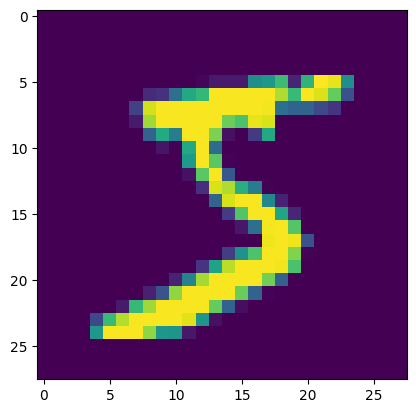

In [71]:
plt.imshow(X_train[0])

With conventional neural networks, we cannot feed in the image as input as is. So we need to flatten the images into one-dimensional vectors, each of size 1 x (28 x 28) = 1 x 784.

In [72]:
# flatten images into one-dimensional vector

num_pixels = X_train.shape[1] * X_train.shape[2] # find size of one-dimensional vector

X_train = X_train.reshape(X_train.shape[0], num_pixels).astype('float32') # flatten training images
X_test = X_test.reshape(X_test.shape[0], num_pixels).astype('float32') # flatten test images

Since pixel values can range from 0 to 255, let's normalize the vectors to be between 0 and 1.

In [73]:
# normalize inputs from 0-255 to 0-1
X_train = X_train / 255
X_test = X_test / 255

Finally, before we start building our model, remember that for classification we need to divide our target variable into categories. We use the to_categorical function from the Keras Utilities package.

In [74]:
# one hot encode outputs
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1]
print(num_classes)

10


Build a Neural Network

In [ ]:
# define classification model
def classification_model():
    # create model

    model = Sequential()
    model.add(Input(shape=(num_pixels,)))
    model.add(Dense(num_pixels, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))


    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

Train and Test the Network

In [80]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Reshape

# Define the classification model
def classification_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Adjust input shape
        Dense(32, activation='relu'),
        Dense(y_train.shape[1] * y_train.shape[2], activation='relu'), # Output enough neurons for the reshaped target
        Reshape(y_train.shape[1:]) # Add a reshape layer to match the target shape
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) # Change the loss function.
    return model

# Now you can call it
model = classification_model()

# Train the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 - 7s - 3ms/step - accuracy: 0.8999 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 2/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 3/10
1875/1875 - 9s - 5ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 4/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 5/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 6/10
1875/1875 - 12s - 6ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 7/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 8/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 9/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 10/10
1875/1875 - 5s - 3ms/ste

Let's print the accuracy and the corresponding error.

In [82]:
# build the model
model = classification_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)

# Print the accuracy and error (this was previously in a separate cell)
print('Accuracy: {}% \n Error: {}'.format(scores[1], 1 - scores[1]))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 - 8s - 4ms/step - accuracy: 0.8999 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 2/10
1875/1875 - 8s - 4ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 3/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 4/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 5/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 6/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 7/10
1875/1875 - 8s - 4ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 8/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 9/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9000 - loss: nan - val_accuracy: 0.9000 - val_loss: nan
Epoch 10/10
1875/1875 - 8s - 4ms/step

Just running 10 epochs could actually take over 20 minutes. But enjoy the results as they are getting generated.

Sometimes, you cannot afford to retrain your model everytime you want to use it, especially if you are limited on computational resources and training your model can take a long time. Therefore, with the Keras library, you can save your model after training. To do that, we use the save method.

In [83]:
model.save('classification_model.keras')

Since our model contains multidimensional arrays of data, then models are usually saved as .keras files.

When you are ready to use your model again, you use the load_model function from keras.saving.

In [84]:
pretrained_model = keras.saving.load_model('classification_model.keras')

Convolutional Neural Networks with Keras
Estimated time needed 30 mins

In this lab, we will learn how to use the Keras library to build convolutional neural networks. We will also use the popular MNIST dataset and we will compare our results to using a conventional neural network.

Objectives for this Notebook
How to use the Keras library to build convolutional neural networks
Convolutional neural network with one set of convolutional and pooling layers
Convolutional neural network with two sets of convolutional and pooling layers
Table of Contents
Import Keras and Packages
Convolutional Neural Network with One Set of Convolutional and Pooling Layers
Convolutional Neural Network with Two Sets of Convolutional and Pooling Layers

Import Keras and Packages
Let's start by importing the keras libraries and the packages that we would need to build a neural network.

In [85]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# If you run this notebook on a different environment, e.g. your desktop, you may need to uncomment and install certain libraries.

!pip install numpy==2.0.2
!pip install pandas==2.2.2
!pip install tensorflow_cpu==2.18.0
!pip install matplotlib==3.9.2

Import Keras and Packages
Let's start by importing the keras libraries and the packages that we would need to build a neural network.

In [86]:
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical

When working with convolutional neural networks in particular, we will need additional packages.

In [87]:
from keras.layers import Conv2D # to add convolutional layers
from keras.layers import MaxPooling2D # to add pooling layers
from keras.layers import Flatten # to flatten data for fully connected layers

Convolutional Neural Network with One Set of Convolutional and Pooling Layers

In [88]:
# import data
from keras.datasets import mnist

# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# reshape to be [samples][pixels][width][height]
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')

Let's normalize the pixel values to be between 0 and 1

In [89]:
X_train = X_train / 255 # normalize training data
X_test = X_test / 255 # normalize test data

Next, let's convert the target variable into binary categories

In [90]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1] # number of categories

Next, let's define a function that creates our model. Let's start with one set of convolutional and pooling layers.

In [91]:
def convolutional_model():

    # create model
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))
    model.add(Conv2D(16, (5, 5), strides=(1, 1), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics=['accuracy'])
    return model

Finally, let's call the function to create the model, and then let's train it and evaluate it.

In [ ]:
# build the model
model = convolutional_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: {} \n Error: {}".format(scores[1], 100-scores[1]*100))

Convolutional Neural Network with Two Sets of Convolutional and Pooling Layers¶
Let's redefine our convolutional model so that it has two convolutional and pooling layers instead of just one layer of each.

In [92]:
def convolutional_model():

    # create model
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))
    model.add(Conv2D(16, (5, 5), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    model.add(Conv2D(8, (2, 2), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    # Compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics=['accuracy'])
    return model

Now, let's call the function to create our new convolutional neural network, and then let's train it and evaluate it.

In [93]:
# build the model
model = convolutional_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: {} \n Error: {}".format(scores[1], 100-scores[1]*100))

Epoch 1/10
300/300 - 24s - 79ms/step - accuracy: 0.8468 - loss: 0.5241 - val_accuracy: 0.9448 - val_loss: 0.1789
Epoch 2/10
300/300 - 39s - 131ms/step - accuracy: 0.9558 - loss: 0.1466 - val_accuracy: 0.9660 - val_loss: 0.1055
Epoch 3/10
300/300 - 41s - 136ms/step - accuracy: 0.9710 - loss: 0.0962 - val_accuracy: 0.9769 - val_loss: 0.0722
Epoch 4/10
300/300 - 21s - 71ms/step - accuracy: 0.9776 - loss: 0.0746 - val_accuracy: 0.9814 - val_loss: 0.0578
Epoch 5/10
300/300 - 40s - 133ms/step - accuracy: 0.9811 - loss: 0.0635 - val_accuracy: 0.9836 - val_loss: 0.0541
Epoch 6/10
300/300 - 21s - 71ms/step - accuracy: 0.9832 - loss: 0.0539 - val_accuracy: 0.9841 - val_loss: 0.0489
Epoch 7/10
300/300 - 41s - 136ms/step - accuracy: 0.9850 - loss: 0.0474 - val_accuracy: 0.9850 - val_loss: 0.0470
Epoch 8/10
300/300 - 40s - 133ms/step - accuracy: 0.9873 - loss: 0.0428 - val_accuracy: 0.9874 - val_loss: 0.0398
Epoch 9/10
300/300 - 21s - 70ms/step - accuracy: 0.9881 - loss: 0.0385 - val_accuracy: 0.98